In [16]:
# %pip install google-cloud-bigquery pandas-gbq scikit-learn matplotlib seaborn ipywidgets -q

In [17]:
import os
import pandas as pd
from google.cloud import bigquery
from sklearn.linear_model import LinearRegression
import ipywidgets as widgets
from IPython.display import display, clear_output

print("--- CLOUD SECURE LINK ESTABLISHED ---")

# Connect Python environment directly to your specific JSON key file
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "pakistan-macro-analytics-17991db4c9f5.json"

client = bigquery.Client()
print(f"[PASS] Local system authenticated to Cloud Project: '{client.project}'")

--- CLOUD SECURE LINK ESTABLISHED ---
[PASS] Local system authenticated to Cloud Project: 'pakistan-macro-analytics'


In [18]:

# f""" lets us dynamically inject your authenticated project ID directly into the path
query = f"""
SELECT DIM_TIME_year, DIM_INDICATOR_id, FACT_value 
FROM `{client.project}.pakistan_macro_warehouse.FACT_ECONOMIC_MEASUREMENT`
WHERE DIM_TIME_year >= 2000
"""

df_raw = client.query(query).to_dataframe()
print(f"[SUCCESS] Connected! Downloaded {len(df_raw)} records from project '{client.project}'.")


c:\Users\Abdul_Wahab\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\cloud\bigquery\table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


[SUCCESS] Connected! Downloaded 656 records from project 'pakistan-macro-analytics'.


In [19]:
print("--- DISCOVERING AVAILABLE INDICATOR KEYS IN YOUR DATAWAREHOUSE ---")

# Pull out just the unique text keys present in your dataset
unique_keys = df_raw['DIM_INDICATOR_id'].unique()

# Print out the exact string values
for key in unique_keys:
    print(f"Key Found: '{key}'")

--- DISCOVERING AVAILABLE INDICATOR KEYS IN YOUR DATAWAREHOUSE ---
Key Found: 'IND_POLICY_RATE_PCT'
Key Found: 'IND_CURRENT_ACCOUNT_USD_BN'
Key Found: 'IND_EXPORTS_USD_BN'
Key Found: 'IND_FOREX_RESERVES_USD_BN'
Key Found: 'IND_IMF_PROGRAM_ACTIVE'
Key Found: 'IND_IMPORTS_USD_BN'
Key Found: 'IND_PUBLIC_DEBT_GDP_PCT'
Key Found: 'IND_TRADE_BALANCE_USD_BN'
Key Found: 'IND_EXPORTS_GDP_PCT'
Key Found: 'IND_GDP_GROWTH_PCT'
Key Found: 'IND_IMPORTS_GDP_PCT'
Key Found: 'IND_LITERACY_RATE_PCT'
Key Found: 'IND_MOBILE_PER_100'
Key Found: 'IND_SERVICES_GDP_PCT'
Key Found: 'IND_TAX_REVENUE_GDP_PCT'
Key Found: 'IND_UNEMPLOYMENT_PCT'
Key Found: 'IND_AGRI_PCT_GDP'
Key Found: 'IND_FDI_PCT_GDP'
Key Found: 'IND_FDI_USD'
Key Found: 'IND_GDP_USD'
Key Found: 'IND_IND_PCT_GDP'
Key Found: 'IND_INFLATION_CPI'
Key Found: 'IND_LABOR_TOTAL'
Key Found: 'IND_EXCHANGE_RATE'
Key Found: 'IND_REMITTANCES_USD'
Key Found: 'IND_POP_TOTAL'


In [20]:
# Shape data into a Wide Matrix for Machine Learning
df_matrix = df_raw.pivot(index='DIM_TIME_year', columns='DIM_INDICATOR_id', values='FACT_value').ffill().bfill()

# Plug in your exact validated data warehouse keys
target_key = 'IND_INFLATION_CPI'       
policy_rate_key = 'IND_POLICY_RATE_PCT' 

ml_data = pd.DataFrame(index=df_matrix.index)
ml_data['Current_Inflation'] = df_matrix[target_key]
ml_data['Current_Policy_Rate'] = df_matrix[policy_rate_key]

# 1-Year Lag Forecast: Shift target data back so this year's metrics point to next year's outcomes
ml_data['Next_Year_Inflation'] = ml_data['Current_Inflation'].shift(-1) 
ml_data_clean = ml_data.dropna()

print("[PASS] Multi-source matrix alignment complete. Chronological lag models built successfully!")
ml_data_clean.tail(5)

[PASS] Multi-source matrix alignment complete. Chronological lag models built successfully!


,Current_Inflation,Current_Policy_Rate,Next_Year_Inflation
DIM_TIME_year,,,
2020,9.740116,7.00,9.496416
2021,9.496416,7.25,19.873860
2022,19.873860,16.00,30.768128
2023,30.768128,22.00,30.768128
2024,30.768128,13.00,30.768128


In [21]:
import numpy as np

# Convert data into clean matrices to avoid strict header warnings
X_matrix = ml_data_clean[['Current_Inflation', 'Current_Policy_Rate']].to_numpy()
y_vector = ml_data_clean['Next_Year_Inflation'].to_numpy()

# Initialize and fit the supervised learning model
forecaster = LinearRegression()
forecaster.fit(X_matrix, y_vector)

print("--- MODEL TRAINING CHARACTERISTICS ---")
print(f"[SUCCESS] Predictive model successfully fitted.")
print(f"Mathematical Formula:")
print(f"Next_Year_Inflation = ({forecaster.coef_[0]:.3f} * Inflation) + ({forecaster.coef_[1]:.3f} * Policy_Rate) + {forecaster.intercept_:.3f}")

--- MODEL TRAINING CHARACTERISTICS ---
[SUCCESS] Predictive model successfully fitted.
Mathematical Formula:
Next_Year_Inflation = (1.086 * Inflation) + (-0.351 * Policy_Rate) + 3.900


In [22]:
import numpy as np

# Re-verify keys for safety
target_key = 'IND_INFLATION_CPI'       
policy_rate_key = 'IND_POLICY_RATE_PCT'

# Extract the baseline inputs from the warehouse matrix
latest_year = df_matrix.index.max()
latest_inflation = float(df_matrix.loc[latest_year, target_key])
latest_policy_rate = float(df_matrix.loc[latest_year, policy_rate_key])

print(f"Latest Warehouse Records Installed ({latest_year}):")
print(f" -> Inflation Rate: {latest_inflation:.2f}% | Central Bank Policy Rate: {latest_policy_rate:.2f}%\n")

# Construct clean sliders for end-user interaction
rate_slider = widgets.FloatSlider(
    value=latest_policy_rate, min=5.0, max=25.0, step=0.25,
    description='Simulate New Interest Rate:', style={'description_width': 'initial'}
)
output_box = widgets.Output()

def run_scenario(change):
    with output_box:
        clear_output(wait=True)
        user_choice = float(rate_slider.value)
        
        # Format the user inputs as a structured 2D array for the machine learning engine
        user_input = np.array([[latest_inflation, user_choice]])
        pred = forecaster.predict(user_input)[0]
        
        print(f"🔮 MACHINE LEARNING FORECAST FOR YEAR {latest_year + 1}:")
        print(f"If the central bank sets the interest rate to: {user_choice:.2f}%")
        print(f"The model predicts Pakistan's upcoming Inflation will be: {pred:.2f}%")

# Connect the slider interaction path to the analytical logic
rate_slider.observe(run_scenario, names='value')

print("--- INTERACTIVE POLICY SIMULATION SANDBOX ---")
display(rate_slider, output_box)

# Run an initial evaluation execution pass
rate_slider.value = latest_policy_rate

Latest Warehouse Records Installed (2025):
 -> Inflation Rate: 30.77% | Central Bank Policy Rate: 11.00%

--- INTERACTIVE POLICY SIMULATION SANDBOX ---


FloatSlider(value=11.0, description='Simulate New Interest Rate:', max=25.0, min=5.0, step=0.25, style=SliderS…

Output()

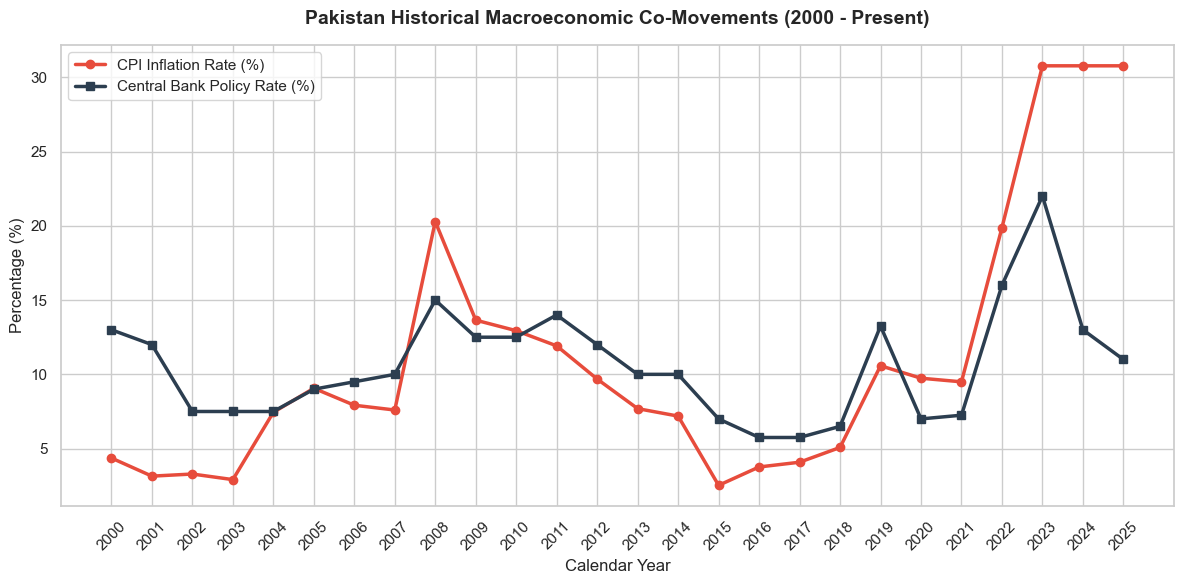

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, academic plot style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot historical Inflation and Policy Rate from your pivoted cloud data
plt.plot(df_matrix.index, df_matrix['IND_INFLATION_CPI'], marker='o', linewidth=2.5, label='CPI Inflation Rate (%)', color='#e74c3c')
plt.plot(df_matrix.index, df_matrix['IND_POLICY_RATE_PCT'], marker='s', linewidth=2.5, label='Central Bank Policy Rate (%)', color='#2c3e50')

# Labeling and Formatting
plt.title("Pakistan Historical Macroeconomic Co-Movements (2000 - Present)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Calendar Year", fontsize=12)
plt.ylabel("Percentage (%)", fontsize=12)
plt.xticks(df_matrix.index, rotation=45)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()

# Display the data plot
plt.show()

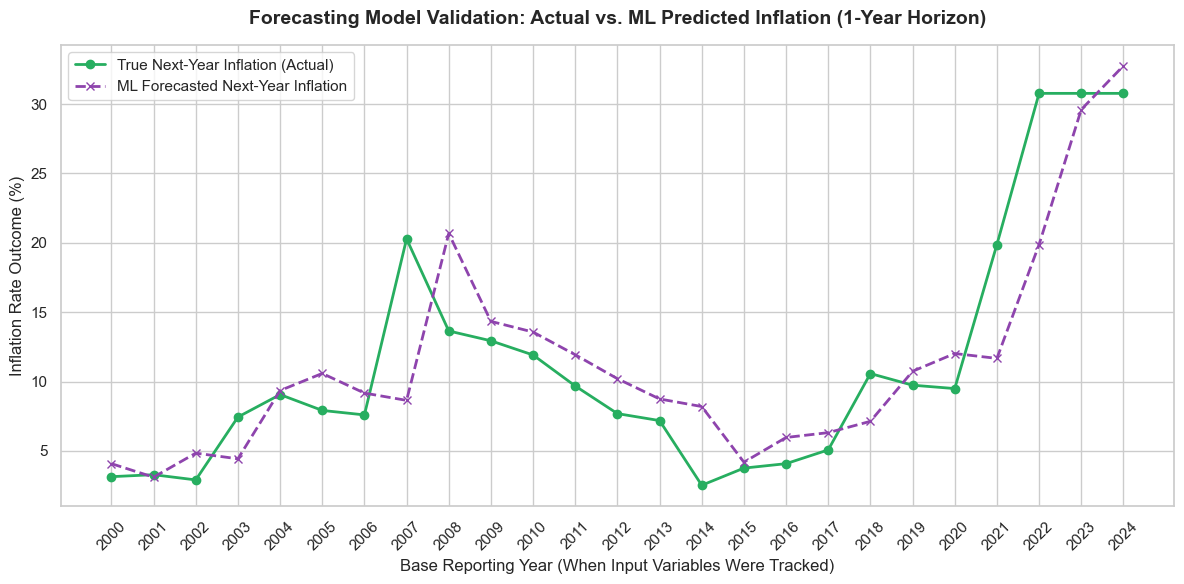

In [25]:
# Use the trained model to generate historical predictions for evaluation
X_matrix = ml_data_clean[['Current_Inflation', 'Current_Policy_Rate']].to_numpy()

# Temporarily catch predictions for plotting (ignoring setting copy warnings safely)
import warnings
warnings.filterwarnings('ignore')
ml_data_clean['Predicted_Next_Year_Inflation'] = forecaster.predict(X_matrix)

plt.figure(figsize=(12, 6))

# Plot True Next Year Inflation vs Predictive Model Paths
plt.plot(ml_data_clean.index, ml_data_clean['Next_Year_Inflation'], marker='o', linestyle='-', linewidth=2, label='True Next-Year Inflation (Actual)', color='#27ae60')
plt.plot(ml_data_clean.index, ml_data_clean['Predicted_Next_Year_Inflation'], marker='x', linestyle='--', linewidth=2, label='ML Forecasted Next-Year Inflation', color='#8e44ad')

# Labeling and Formatting
plt.title("Forecasting Model Validation: Actual vs. ML Predicted Inflation (1-Year Horizon)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Base Reporting Year (When Input Variables Were Tracked)", fontsize=12)
plt.ylabel("Inflation Rate Outcome (%)", fontsize=12)
plt.xticks(ml_data_clean.index, rotation=45)
plt.legend(fontsize=11, loc='upper left')
plt.tight_layout()

plt.show()


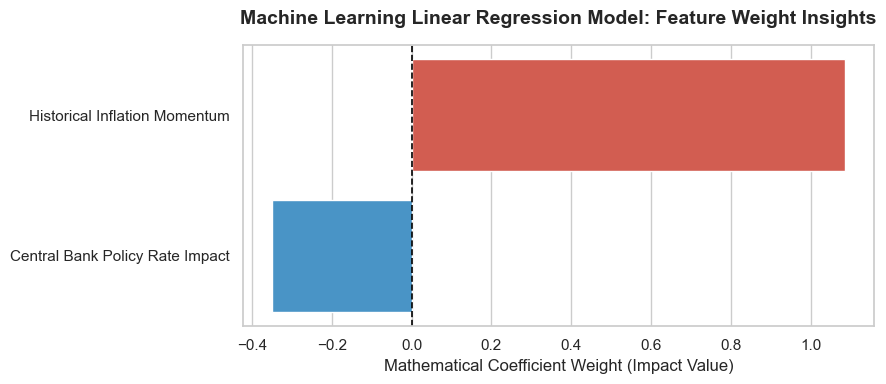

In [26]:
# Define feature labels and map out weights extracted directly from the model
features = ['Historical Inflation Momentum', 'Central Bank Policy Rate Impact']
coefficients = forecaster.coef_

plt.figure(figsize=(9, 4))
# Red bars indicate positive upward push, blue indicates negative damping pull
colors = ['#e74c3c' if c > 0 else '#3498db' for c in coefficients]

sns.barplot(x=coefficients, y=features, palette=colors, hue=features, legend=False)

# Add a baseline marker axis at zero alignment
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.2)

# Labeling and Formatting
plt.title("Machine Learning Linear Regression Model: Feature Weight Insights", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Mathematical Coefficient Weight (Impact Value)", fontsize=12)
plt.tight_layout()

plt.show()